# House Price Prediction

### PROBLEM STATEMENT

Accurately predicting house prices is a critical task for buyers, sellers, and real
estate professionals. This project uses the Ames Housing dataset to build a
regression model that predicts a house's sale price based on its physical
characteristics, quality ratings, and location.

The goal is to compare multiple regression models, engineer meaningful features
from the raw data, and tune the best-performing model to produce accurate,
interpretable price predictions.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

import joblib

## 1. Load the Data

In [69]:
home = pd.read_csv('train.csv')
home.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [70]:
home.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

The code above shows the basic information about the data set like number of columns, data type of columns and nuber of rows.

In [71]:
home.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The code above shows the statistical information about the data set 

In [72]:
home.dtypes


Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [73]:
home.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 2. Data Cleaning

Handling missing values by displaying columns with missing values, along side the amount of missing values they have and filling them with the median of the entire row, none in case of missing categorical values, mode of the entire columns and 0s where necessary

Displaying missing values for columns containing missing values

In [74]:
missing = home.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


Filling missing values with the median of the entire column, none in case of missing categorical values, mode of the entire columns and 0s where necessary

In [75]:
none_fill_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                   'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond',
                   'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType1',
                   'MasVnrType']
for col in none_fill_cols:
    home[col] = home[col].fillna('None')

home['GarageYrBlt'] = home['GarageYrBlt'].fillna(0)
home['MasVnrArea'] = home['MasVnrArea'].fillna(0)
home['LotFrontage'] = home['LotFrontage'].fillna(home['LotFrontage'].median())
home['Electrical'] = home['Electrical'].fillna(home['Electrical'].mode()[0])

print(home.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


## 3. Outlier Removal(Capping method)

Applied to the key numerical columns to reduce the influence of extreme values
before feature engineering.

Text(0.5, 1.0, 'Boxplot of saleprice before outlier removal')

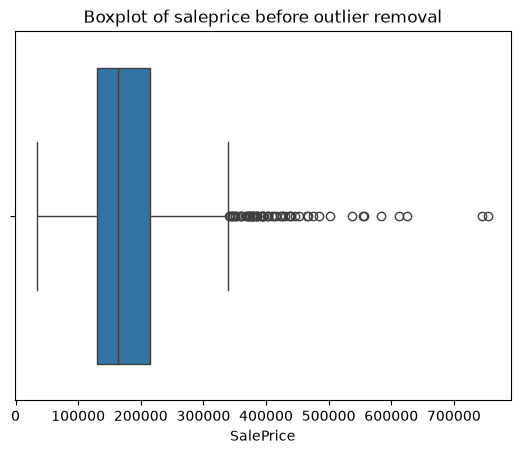

In [76]:
sns.boxplot(x = home['SalePrice'])
plt.title('Boxplot of saleprice before outlier removal')

The boxplot above shows that there are outliers present in the saleprice column

Capping works by setting a maximum and/or minimum limit on values in a 
numerical column. Any value above the maximum limit is replaced with the 
maximum, and any value below the minimum limit is replaced with the minimum.

In [77]:
def cap_outliers_iqr(df, columns, factor=1.5):
    df_capped = df.copy()
    
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        # Calculate how many values fall outside boundaries before capping
        lower_outliers = (df_capped[col] < lower_bound).sum()
        upper_outliers = (df_capped[col] > upper_bound).sum()
        
        # Clip feature values to calculated IQR boundaries
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
        print(f"{col:12s} | Lower capped: {lower_outliers:3d} | Upper capped: {upper_outliers:3d} | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        
    return df_capped

# Target features from dataset analysis
features_to_cap = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'SalePrice']

# Perform capping
home = cap_outliers_iqr(home, features_to_cap)

GrLivArea    | Lower capped:   0 | Upper capped:  31 | Bounds: [158.62, 2747.62]
LotArea      | Lower capped:   2 | Upper capped:  67 | Bounds: [1481.50, 17673.50]
TotalBsmtSF  | Lower capped:  37 | Upper capped:  24 | Bounds: [42.00, 2052.00]
SalePrice    | Lower capped:   0 | Upper capped:  61 | Bounds: [3937.50, 340037.50]


<Axes: xlabel='SalePrice'>

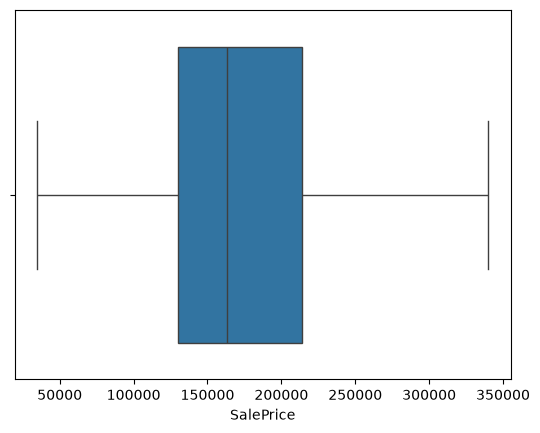

In [78]:
sns.boxplot(x = home['SalePrice'])

The box plot above shows that the saleprice column is more clean due to removal of outliers

## 4. Feature Engineering

New features that capture combined/derived information the raw columns don't
express on their own.

In [79]:
home['house_age'] = home['YrSold'] - home['YearBuilt']
home['total_sqft'] = home['TotalBsmtSF'] + home['1stFlrSF'] + home['2ndFlrSF']
home['area_per_room'] = home['GrLivArea'] / (home['TotRmsAbvGrd'] + 1)
home['garage_area_ratio'] = home['GarageArea'] / (home['GrLivArea'] + 1)
home['overall_space'] = home['GrLivArea'] + home['GarageArea']

Feature engineering was performed inorder for the model to find new patterns when learning

## 5. Target Transformation

Log transform was performed on Sale price inorder for the values to be distributed evenly so that the model wont focus or treat some with more importance than the other 

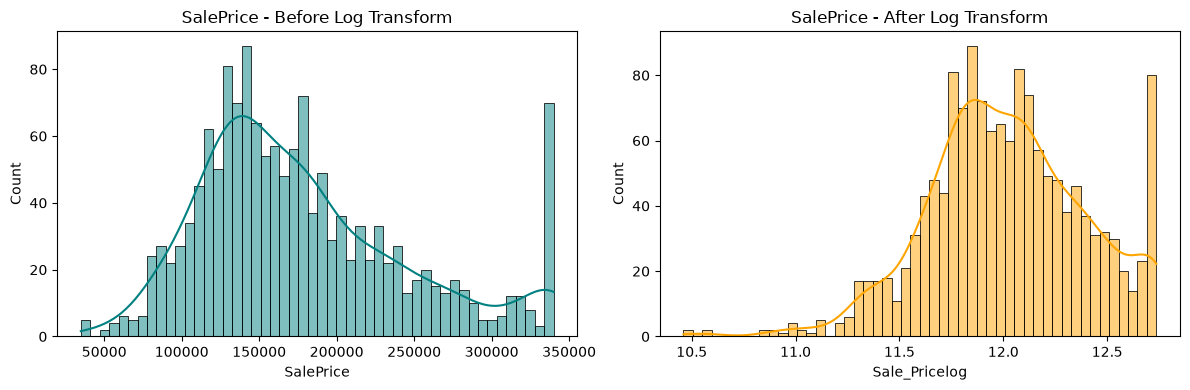

In [80]:
home['Sale_Pricelog'] = np.log1p(home['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(home['SalePrice'], bins=50, color='teal', edgecolor='black',ax = axes[0], kde = True)
axes[0].set_title('SalePrice - Before Log Transform')
sns.histplot(home['Sale_Pricelog'], bins=50, color='orange', edgecolor='black',kde = True, ax = axes[1])
axes[1].set_title('SalePrice - After Log Transform')
plt.tight_layout()
plt.show()

The subplots above shows the before and after log transform of saleprice. The Sale price before the log transform was right skewed and the Sale price after the log transform is more evenly distributed.

## 6. Exploratory Data Analysis

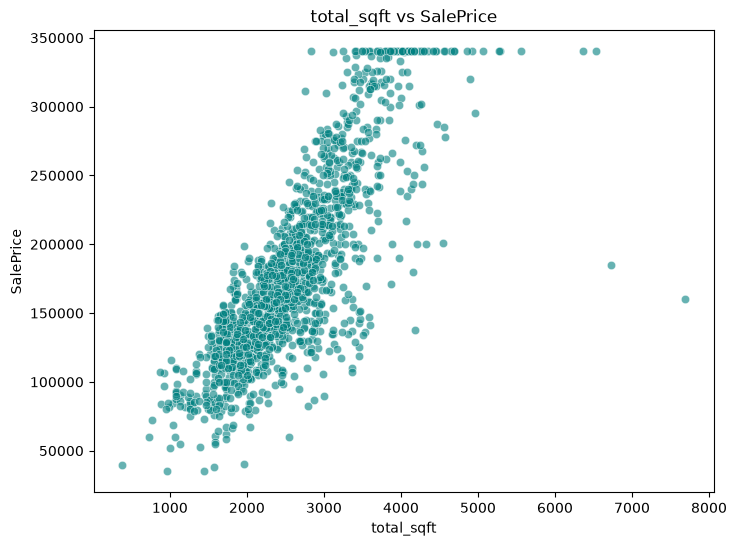

In [81]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_sqft', y='SalePrice', data=home, alpha=0.6, color='teal')
plt.title('total_sqft vs SalePrice')
plt.show()

The scatter plot above shows that if  the total size(in square feet) of the home increases the price would also increase. This shows a positive correlation with SalePrice

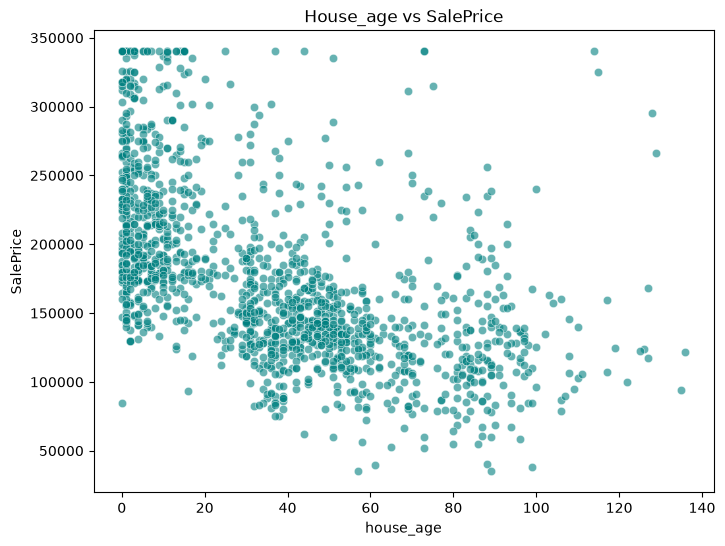

In [82]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='house_age', y='SalePrice', data=home, alpha=0.6, color='teal')
plt.title('House_age vs SalePrice')
plt.show()

The scatter plot above shows that if the age of the house increases the price of the homw would also reduce. This shows a negative corellation with Sale price

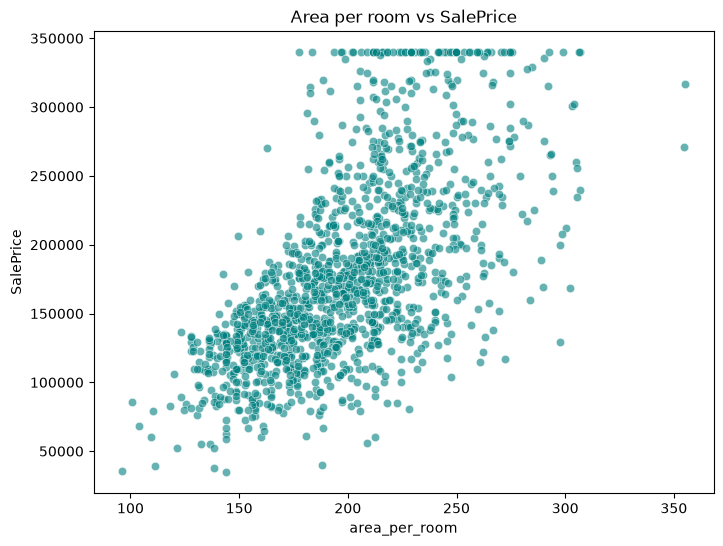

In [83]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='area_per_room', y='SalePrice', data=home, alpha=0.6, color='teal')
plt.title('Area per room vs SalePrice')
plt.show()

Text(0.5, 1.0, 'Neighbourhoods with the highest average saleprice')

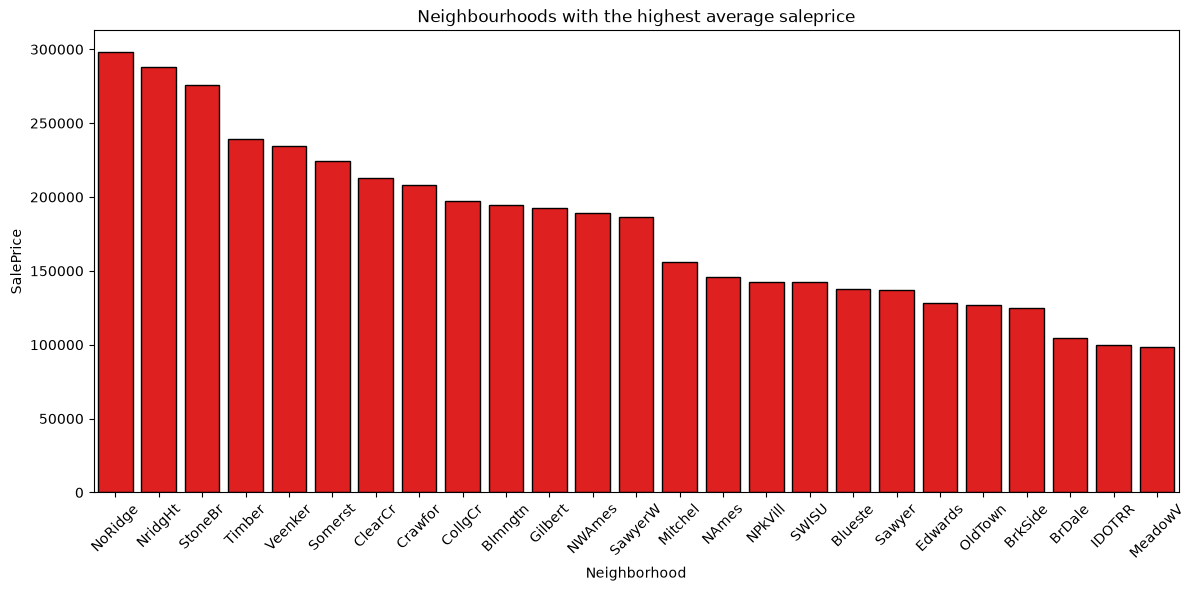

In [84]:
plt.figure(figsize = (14,6))
home_neighborhood = home.groupby('Neighborhood')[['SalePrice']].mean()
home_neighborhood = home_neighborhood.sort_values(by=['SalePrice'], ascending= False)
sns.barplot(x = 'Neighborhood', y = 'SalePrice', data = home_neighborhood , color = 'red', edgecolor = 'black')
plt.xticks(rotation = 45)
plt.title('Neighbourhoods with the highest average saleprice')


The barplot above shows the neighbourhoods with the highest average sale price. Norrige had the highest average with an average price of homes exceeding 250000 dollars

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

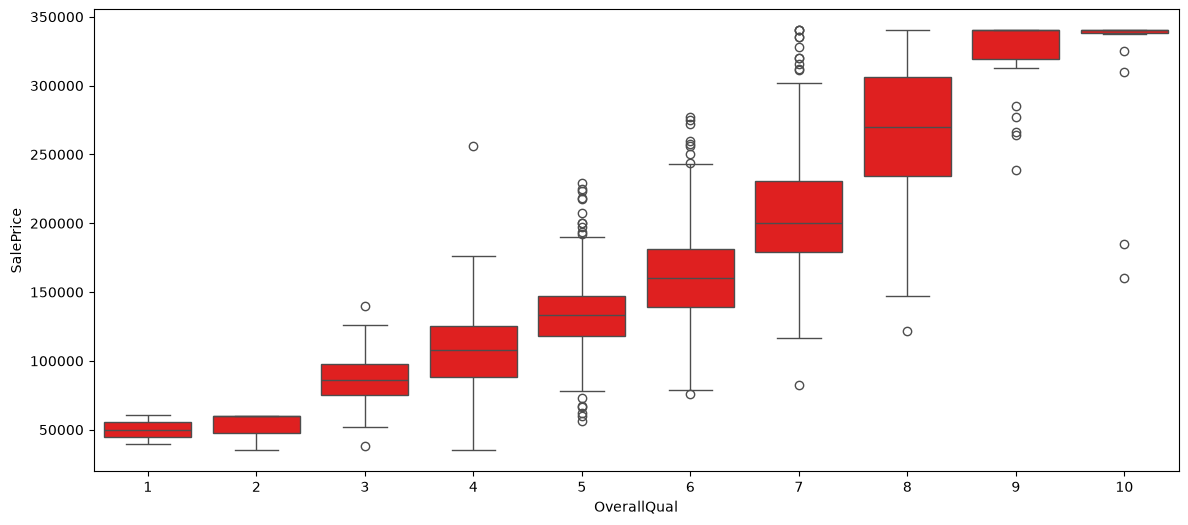

In [85]:
plt.figure(figsize = (14,6))
sns.boxplot(x = 'OverallQual', y = 'SalePrice', data = home , color = 'red')


In [86]:
numeric_cols = home.select_dtypes(include=['number']).columns.tolist()

In [87]:
cols_to_drop = [
    'YrSold', 
    'YearBuilt', 
    'TotalBsmtSF', 
    '1stFlrSF', 
    '2ndFlrSF', 
    'GrLivArea', 
    'TotRmsAbvGrd', 
    'GarageArea',
    'Sale_Pricelog',
    'overall_space'
]
corr_cols = [col for col in numeric_cols if col not in cols_to_drop]

Columns which could lead to multicollinearity were removed inorder for the hat map to look more clean

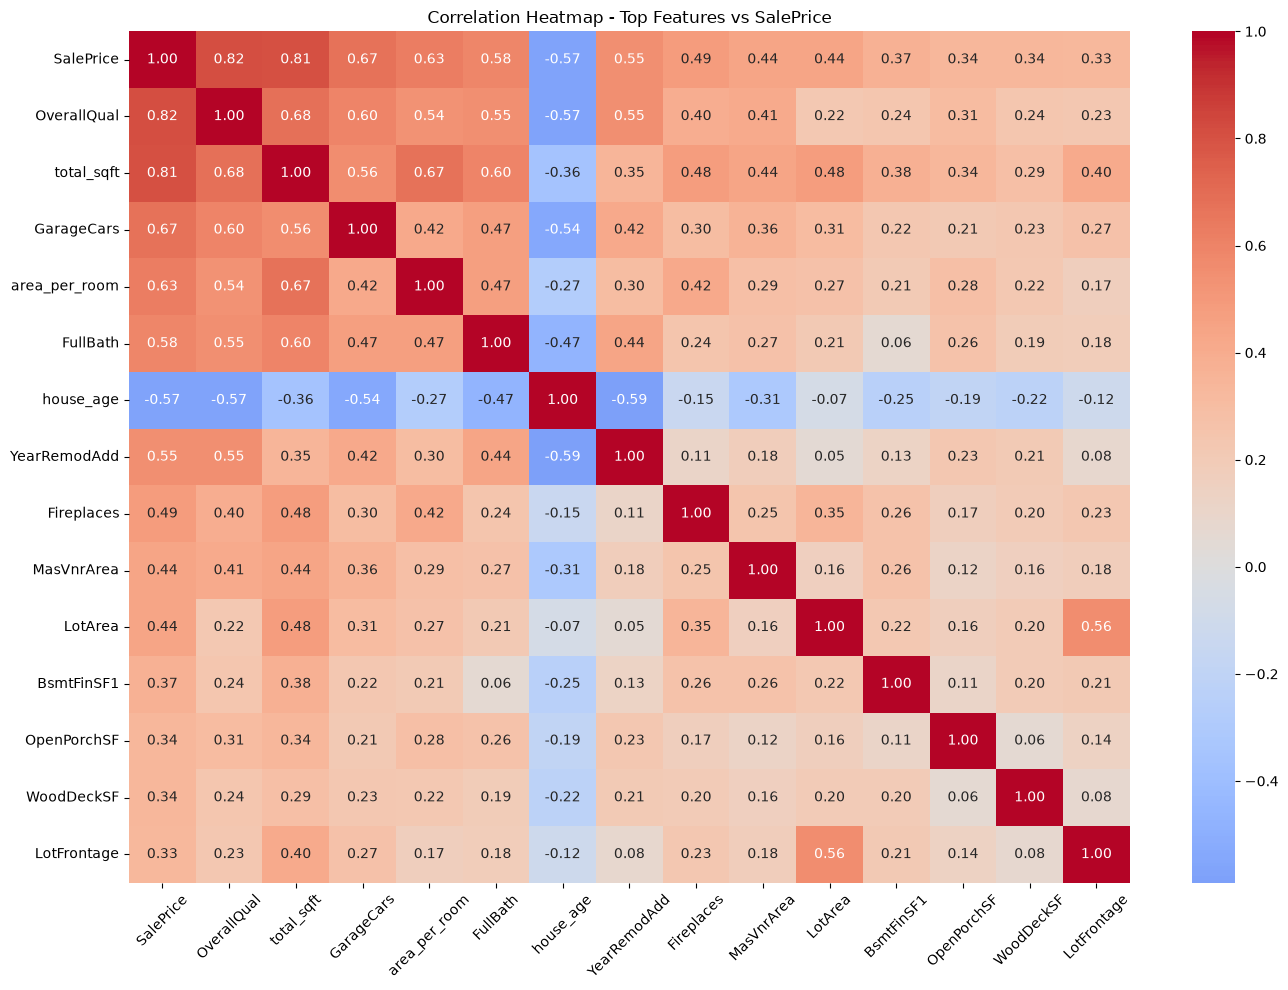

In [88]:
plt.figure(figsize=(14, 10))
corr = home[corr_cols].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(home[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features vs SalePrice')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The corellation heat map above show the corellation of features with sale price and the corellation of features with each other. Features like overallqual(overall quality of home ), total_sqft(total size of the home )and Garage cars show strong positive corellation with Saleprice meaning the more they increase, the more the Saleprice increase.While House age was the only feature that showed a strong negative corellation with sale price meaning that the more hose age increases, the less the sale price decreases



## 7. Encoding

One-hot encode categorical columns. Because the split happened first, the training
set and test set are encoded separately, and the test set's columns are then
aligned to match the training set's columns exactly (any category seen only in
test gets dropped, any category seen only in train gets added to test as all-zero).
This mirrors how the encoding would behave on genuinely new data at inference
time.

In [89]:
cat_cols = home.select_dtypes(include = 'object').columns
train_encoded = pd.get_dummies(home,columns= cat_cols,drop_first= True)
x = train_encoded.drop(columns = ['SalePrice'
                                  ,'Sale_Pricelog'
                                  ,'YrSold', 
    'YearBuilt', 
    'TotalBsmtSF', 
    '1stFlrSF', 
    '2ndFlrSF', 
    'GrLivArea', 
    'TotRmsAbvGrd', 
    'GarageArea',
    'overall_space'])
y = home['Sale_Pricelog']

C:\Users\alegb\AppData\Local\Temp\ipykernel_24084\936170317.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = home.select_dtypes(include = 'object').columns


## 8. Train-Test split

The data was then splitted into 80% for training and 20% for testing 

In [90]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 23)

## 9. Scaling

Scaling involves transforming your feature values into a consistent range, so that no single feature dominates the model because of its magnitude.Scaling was fitted on only the training data so that the data wont be leaked to the model.

In [91]:
scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled  = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

## 8. Recursive Feature Elimination with Cross-Validation (RFECV)

RFECV works like a survival tournament — the weakest features are continuously 
voted out round by round, with cross-validation acting as the judge deciding 
which features are actually contributing to performance.

At each round, RFECV trains the estimator (Ridge, in this case), ranks features 
by importance, and eliminates the least important one. This cycle repeats until 
every possible feature count has been tested. The number of features at the 
point of peak cross-validated score is the number RFECV selects as optimal.

In [122]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV

# 1. Lock the seed in the cross-validator
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Lock the seed in the estimator (Ridge usually relies on a seed for certain solvers like 'sag')
estimator = Ridge(alpha=10.0, random_state=42)

# 3. Initialize RFECV
rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1
)

rfecv.fit(x_train, y_train)


,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,Ridge(alpha=1...ndom_state=42)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'r2'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scores over the folds.n_features : ndarray of shape (n_subsets_of_features,) Number of features used at each step. .. versi

In [123]:
selected_features = x_train.columns[rfecv.support_]
print("Selected features:", list(selected_features))

x_train_rfecv = x_train[selected_features]
x_test_rfecv = x_test[selected_features]  # apply the SAME selection to test set

Selected features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'house_age', 'total_sqft', 'area_per_room', 'garage_area_ratio', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'Alley_None', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neigh

## 9.  Baseline Model Comparison

In [124]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(random_state=23),
    'XGBoost': XGBRegressor(random_state=23)
}

y_test_actual = np.expm1(y_test)
results = []

for name, model in models.items():
    model.fit(x_train_rfecv, y_train)
    log_preds = model.predict(x_test_rfecv)
    actual_preds = np.expm1(log_preds)

    r2 = r2_score(y_test_actual, actual_preds)
    mse = mean_squared_error(y_test_actual, actual_preds)
    rmse = np.sqrt(mse)

    results.append({'Model': name, 'R2': round(r2, 4), 'MSE': round(mse, 2), 'RMSE': round(rmse, 2)})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results_df)

,Model,R2,MSE,RMSE
2,Lasso,0.9179,3.668318e+08,19152.85
1,Ridge,0.9122,3.925617e+08,19813.17
3,Random Forest,0.9085,4.087336e+08,20217.16
4,XGBoost,0.9075,4.133271e+08,20330.45
0,Linear Regression,0.8825,5.249943e+08,22912.75


## 10. Hyperparameter Tuning

Only the top performers get tuned. Ridge (or the best linear model) uses
GridSearchCV since its search space is small; the best tree-based model uses
RandomizedSearchCV since its search space is much larger.

In [125]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(x_train_rfecv, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge CV R2:", round(ridge_grid.best_score_, 4))

Best Ridge alpha: {'alpha': 50}
Best Ridge CV R2: 0.8807


In [126]:
# --- XGBoost Tuning (RandomizedSearchCV) ---
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25,30,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
}
rf_random = RandomizedSearchCV(
RandomForestRegressor(random_state=23), rf_params, n_iter=50, cv=5,
scoring='r2', random_state=23, n_jobs=-1)

rf_random.fit(x_train_rfecv, y_train)

print("Best rf params:", rf_random.best_params_)
print("Best rf CV R2:", round(rf_random.best_score_, 4))

Best rf params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best rf CV R2: 0.8735


## 11. Evaluate Tuned Models on the Test Set

In [108]:
tuned_models = {
    'Ridge (tuned)': ridge_grid.best_estimator_,
    'Randomforest (tuned)': rf_random.best_estimator_
}

for name, model in tuned_models.items():
    log_preds = model.predict(rfecv.transform(x_test))
    actual_preds = np.expm1(log_preds)
    r2 = r2_score(y_test_actual, actual_preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual, actual_preds))
    print(f"{name}: R2={r2:.4f}, RMSE=${rmse:,.2f}")

Ridge (tuned): R2=0.9227, RMSE=$18,582.45
Randomforest (tuned): R2=0.9113, RMSE=$19,913.01


## 12. Diagnostics — Actual vs Predicted, Residuals, Feature Importance

Using the tuned Ridge model as the final model 

c:\Users\alegb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


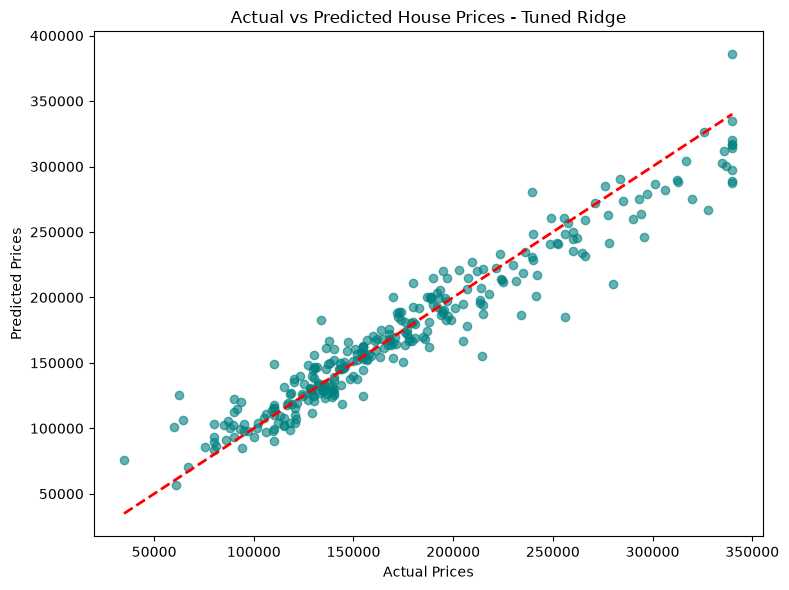

In [120]:
final_model = ridge_grid.best_estimator_

log_preds = final_model.predict(x_test_rfecv)
actual_preds = np.expm1(log_preds)
actual_y = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(actual_y, actual_preds, alpha=0.6, color='teal')
plt.plot([actual_y.min(), actual_y.max()], [actual_y.min(), actual_y.max()], 'r--', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices - Tuned Ridge')
plt.tight_layout()
plt.show()

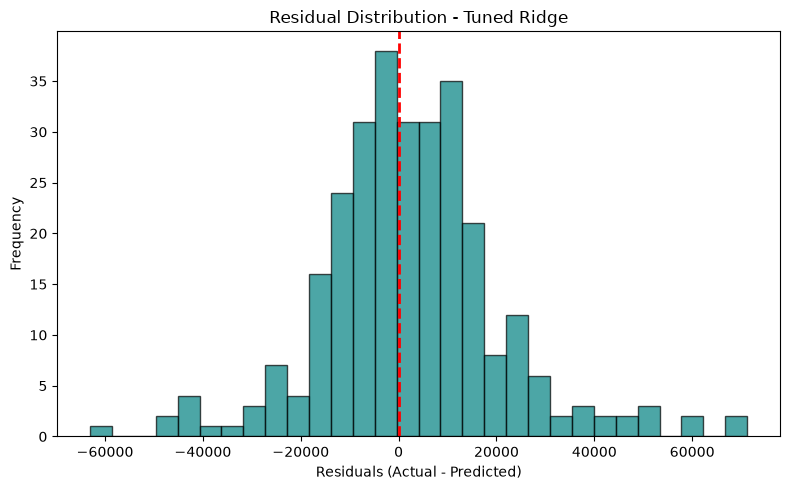

Mean residual: $2,482.25
Std of residuals: $18,447.53


In [111]:
residuals = actual_y - actual_preds

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution - Tuned Ridge')
plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}")
print(f"Std of residuals: ${residuals.std():,.2f}")

In [ ]:
selected_features = x_train.columns[rfecv.support_]
print("Selected features:", list(selected_features))

x_train_rfecv = x_train[selected_features]
x_test_rfecv = x_test[selected_features]  # apply the SAME selection to test set

Selected features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'house_age', 'total_sqft', 'area_per_room', 'garage_area_ratio', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'Alley_None', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neigh

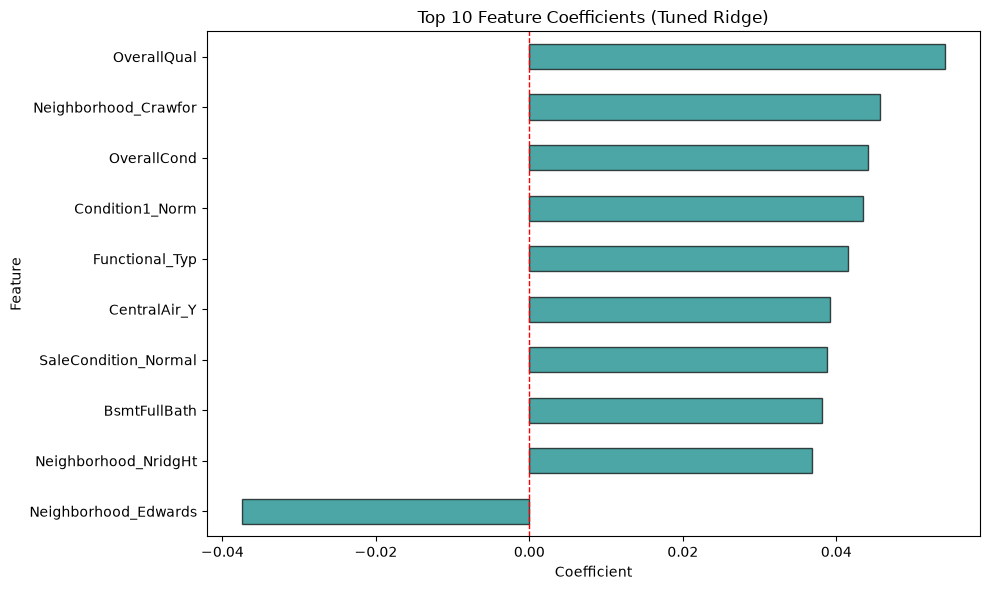

In [119]:
coefficients = pd.Series(final_model.coef_, index = x_train_rfecv.columns)
top_features = coefficients.sort_values(key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='teal', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Feature Coefficients (Tuned Ridge)')
plt.tight_layout()
plt.show()

## 13. Save the Model

In [100]:
joblib.dump(final_model, 'ridge_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(x_rfe.columns), 'feature_names.pkl')            # RFE-selected features the model uses
joblib.dump(x_scaled.columns.tolist(), 'all_feature_names.pkl')  # full pre-RFE feature list the scaler expects
joblib.dump(x_scaled.median(), 'feature_medians.pkl')            # medians to fill features not exposed to the user

print("Model, scaler, feature names and medians saved successfully.")

NameError: name 'x_rfe' is not defined

## 14. Conclusion

This project built an end-to-end machine learning pipeline to predict house
prices. After data cleaning, feature engineering, and exploratory analysis,
five models were compared, and the top performer(s) were tuned with
GridSearchCV / RandomizedSearchCV.

Key findings:
- Overall quality and condition are the strongest drivers of price.
- House age negatively affects price — older houses are worth less.
- Engineered features (`total_sqft`, `house_age`) ranked among the most
  important predictors, confirming the feature engineering added real value.
- Log-transforming the target improved model behavior and produced residuals
  centered near zero with no major systematic bias.

The final tuned model and its supporting artifacts (scaler, feature list,
medians) were saved for use in a deployed prediction API.